## EN3160 Assignment 01 -  Intensity Transformations and Neighborhood Filtering

### Question 1

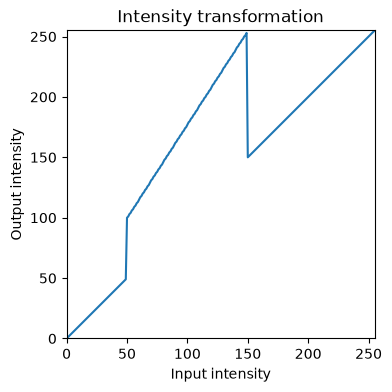

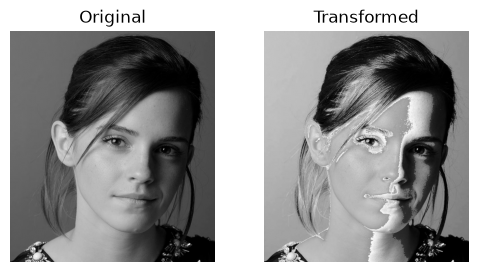

In [38]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    bp = np.array(breakpoints, dtype=float)
    xs, ys = bp[:, 0], bp[:, 1]
    lut = np.zeros(256, dtype='uint8')
    for i in range(len(bp) - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i + 1], ys[i + 1]
        x0i, x1i = int(x0), int(x1)
        if x1i == x0i: 
            continue
        seg = np.linspace(y0, y1, x1i - x0i + 1)
        if i < len(bp) - 2: 
            lut[x0i:x1i] = seg[:-1].astype('uint8')
        else:                  
            lut[x0i:x1i + 1] = seg.astype('uint8')

    transformed = cv.LUT(im, lut)
    return transformed, lut

breakpoints = [(0, 0), (50, 50), (50, 100), (150, 255), (150,150), (255, 255)]
img_orig = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)   # <-- change filename to match your file
img_transformed, lut = intensity_transform(img_orig, breakpoints)

plt.figure(figsize=(4, 4))
plt.plot(lut)
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.title('Intensity transformation')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_orig, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_transformed, cmap='gray')
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

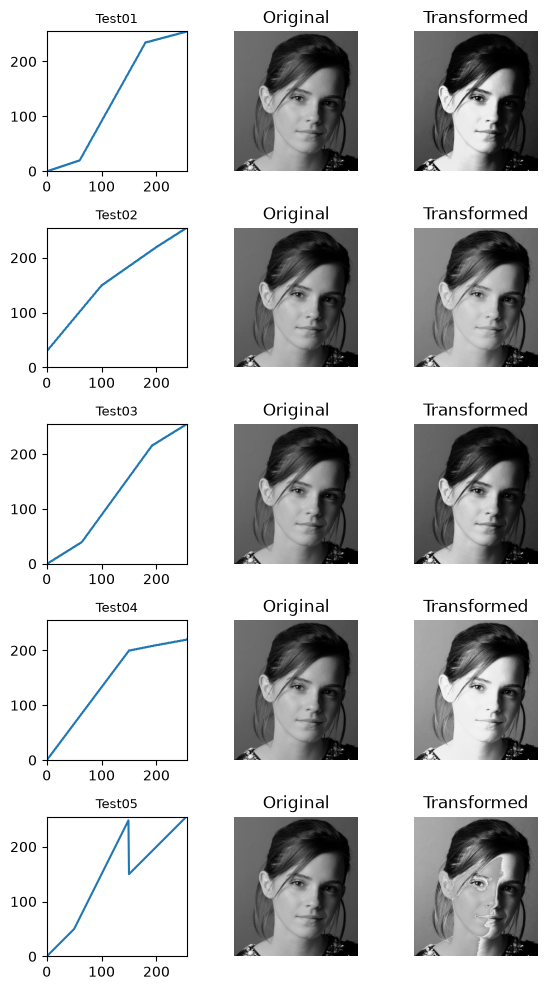

In [39]:
test_breakpoints = {
    "Test01": [(0, 0), (60, 20), (180, 235), (255, 255)],
    "Test02": [(0, 30), (100, 150), (200, 220), (255, 255)],
    "Test03": [(0, 0), (64, 40), (128, 128), (192, 216), (255, 255)],
    "Test04": [(0, 0), (150, 200), (200, 210), (255, 220)],
    "Test05": [(0, 0), (50, 50), (150, 250), (150, 150), (255, 255)],
}
fig, axes = plt.subplots(len(test_breakpoints), 3, figsize=(6, 2 * len(test_breakpoints)))

for row, (label, bp) in enumerate(test_breakpoints.items()):
    transformed, lut = intensity_transform(img_orig, bp)
    
    axes[row, 0].plot(lut)
    axes[row, 0].set_xlim(0, 255); axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_title(label, fontsize=9)

    axes[row, 1].imshow(img_orig, cmap='gray')
    axes[row, 1].set_title('Original'); axes[row, 1].axis('off')

    axes[row, 2].imshow(transformed, cmap='gray')
    axes[row, 2].set_title('Transformed'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

### Question 2

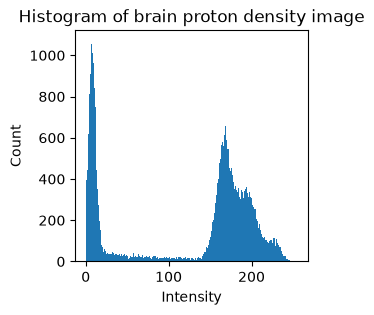

In [40]:
img_orig = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(3, 3))
plt.hist(img_orig.ravel(), bins=256, range=(0, 255))
plt.title('Histogram of brain proton density image')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()

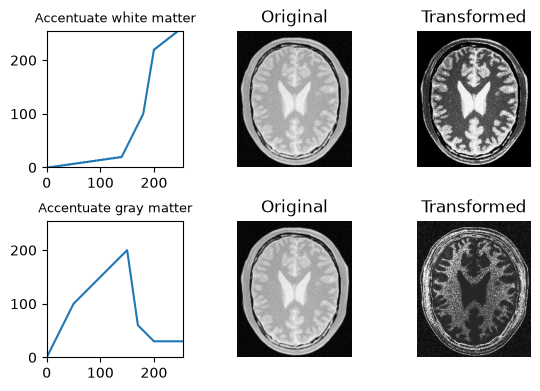

In [41]:
transforms = {
    "Accentuate white matter": [(0, 0), (140, 20), (180, 100), (200, 220), (245, 255), (255, 255)],
    "Accentuate gray matter": [(0, 0), (50, 100), (150, 200), (170, 60), (200, 30), (255, 30)],
}
fig, axes = plt.subplots(len(transforms), 3, figsize=(6, 2 * len(transforms)))

for row, (label, bp) in enumerate(transforms.items()):
    transformed, lut = intensity_transform(img_orig, bp)

    axes[row, 0].plot(lut)
    axes[row, 0].set_xlim(0, 255); axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_title(label, fontsize=9)

    axes[row, 1].imshow(img_orig, cmap='gray')
    axes[row, 1].set_title('Original'); axes[row, 1].axis('off')

    axes[row, 2].imshow(transformed, cmap='gray')
    axes[row, 2].set_title('Transformed'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

### Question 3

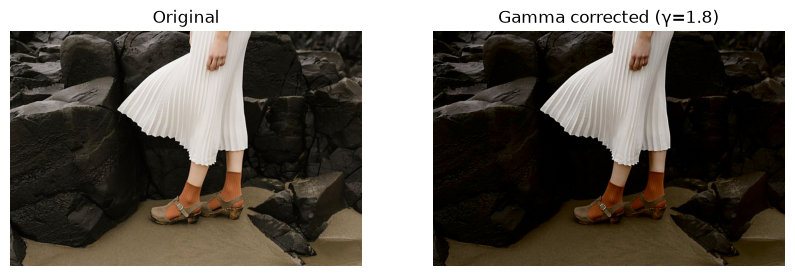

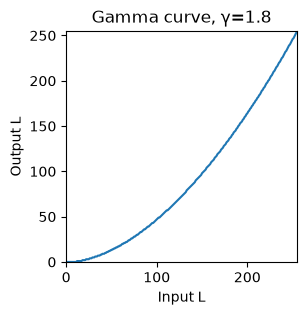

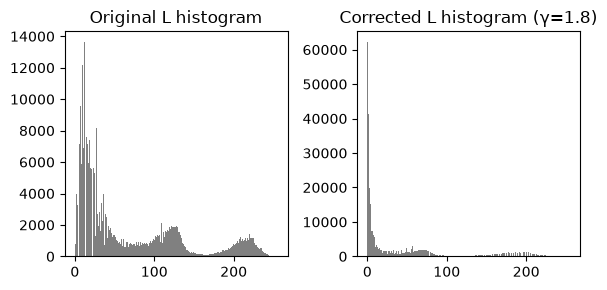

In [42]:
img_bgr = cv.imread('images/q3.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

L, a, b = cv.split(img_lab)
gamma = 1.8
lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype='uint8')
L_corrected = cv.LUT(L, lut)

img_lab_corrected = cv.merge([L_corrected, a, b])
img_bgr_corrected = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2BGR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(img_bgr_corrected, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (γ={gamma})'); axes[1].axis('off')
plt.show()

plt.figure(figsize=(3, 3))
plt.plot(lut)
plt.xlim(0, 255); plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.xlabel('Input L'); plt.ylabel('Output L')
plt.title(f'Gamma curve, γ={gamma}')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original L histogram')
axes[1].hist(L_corrected.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title(f'Corrected L histogram (γ={gamma})')
plt.tight_layout()
plt.show()

### Question 4

#### (a) Split into hue, saturation, and value planes

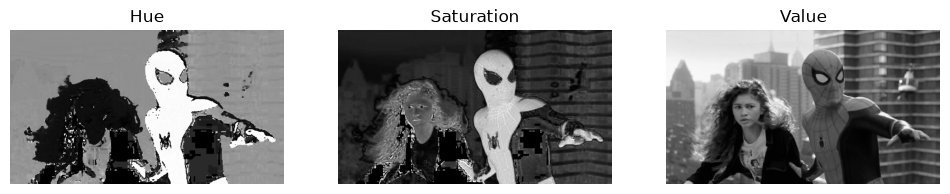

In [43]:
img_bgr = cv.imread('images/q4.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(img_hsv)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(h, cmap='gray'); axes[0].set_title('Hue'); axes[0].axis('off')
axes[1].imshow(s, cmap='gray'); axes[1].set_title('Saturation'); axes[1].axis('off')
axes[2].imshow(v, cmap='gray'); axes[2].set_title('Value'); axes[2].axis('off')
plt.show()

#### (b) Apply the vibrance transformation to the saturation plane

In [44]:
def vibrance_lut(a, sigma=70):
    x = np.arange(256, dtype=np.float64)
    f = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    f = np.clip(f, 0, 255)
    return f.astype('uint8')

a = 0.6 
sigma = 70
lut = vibrance_lut(a, sigma)
s_vibrant = cv.LUT(s, lut)

#### (c) Adjust a and report the value

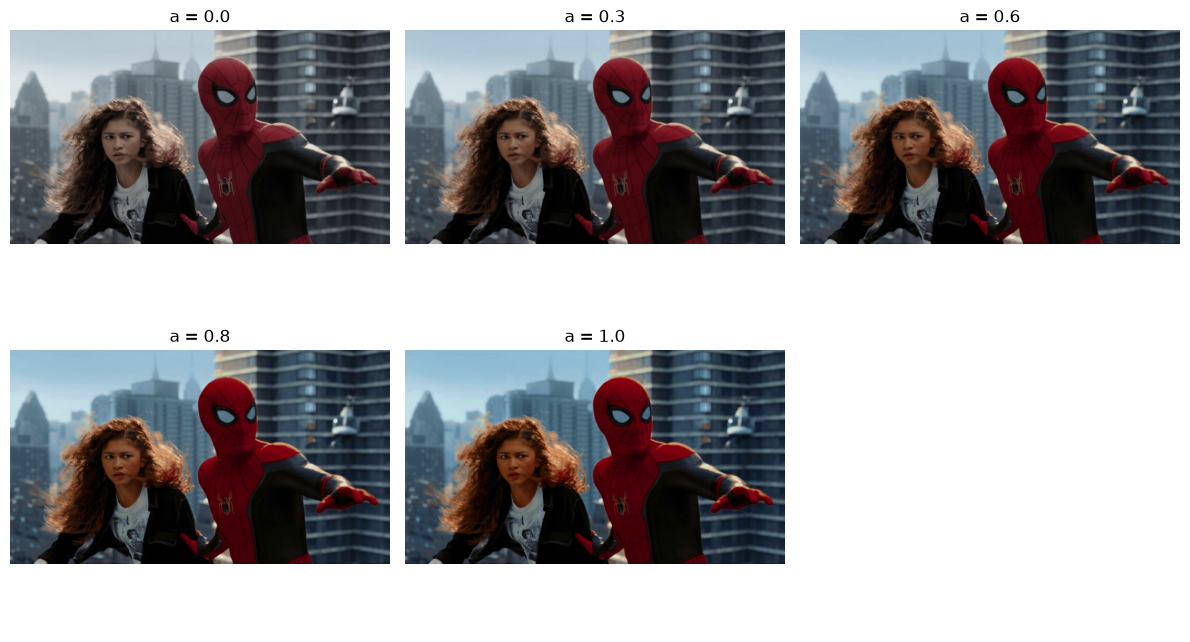

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
a_values = [0.0, 0.3, 0.6, 0.8, 1.0]

for ax, a_test in zip(axes.ravel(), a_values):
    lut_test = vibrance_lut(a_test, sigma)
    s_test = cv.LUT(s, lut_test)
    hsv_test = cv.merge([h, s_test, v])
    bgr_test = cv.cvtColor(hsv_test, cv.COLOR_HSV2BGR)
    ax.imshow(cv.cvtColor(bgr_test, cv.COLOR_BGR2RGB))
    ax.set_title(f'a = {a_test}')
    ax.axis('off')

axes.ravel()[-1].axis('off') 
plt.tight_layout()
plt.show()

a = 0.6 
lut = vibrance_lut(a, sigma)
s_vibrant = cv.LUT(s, lut)

#### (d) Recombine the three planes

In [46]:
img_hsv_vibrant = cv.merge([h, s_vibrant, v])
img_bgr_vibrant = cv.cvtColor(img_hsv_vibrant, cv.COLOR_HSV2BGR)

#### (e) Display original, vibrance-enhanced image, and the intensity transformation

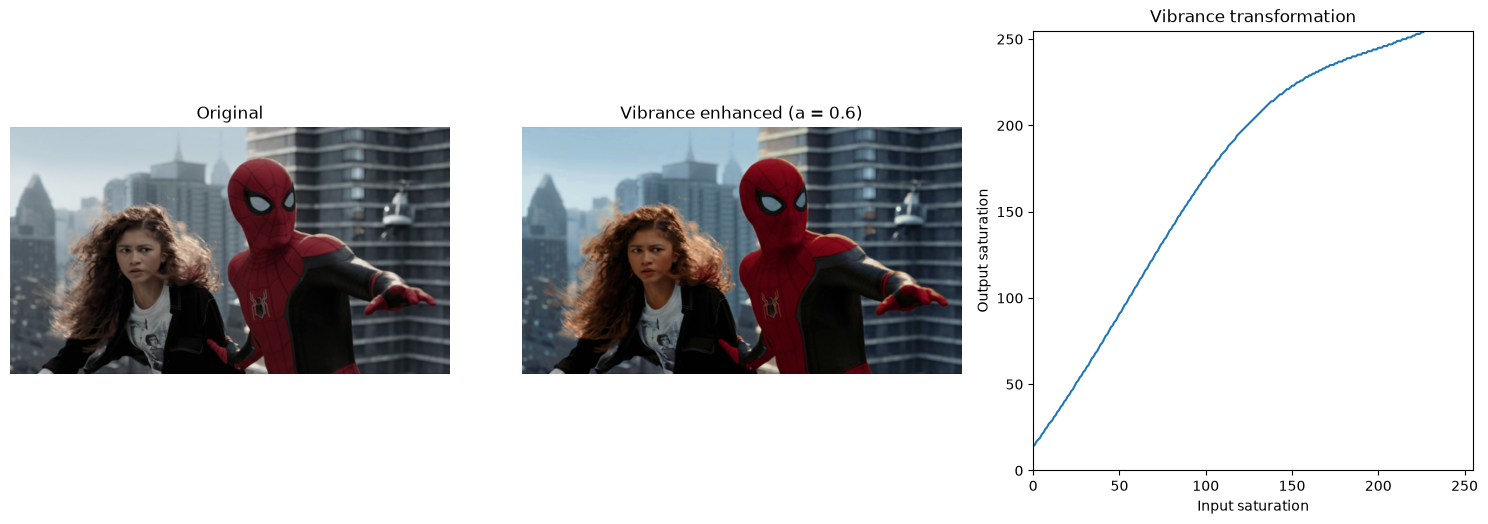

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(img_bgr_vibrant, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance enhanced (a = {a})')
axes[1].axis('off')

axes[2].plot(lut)
axes[2].set_xlim(0, 255); axes[2].set_ylim(0, 255)
axes[2].set_aspect('equal')
axes[2].set_xlabel('Input saturation')
axes[2].set_ylabel('Output saturation')
axes[2].set_title('Vibrance transformation')

plt.tight_layout()
plt.show()

### Question 5

Max abs difference vs cv.equalizeHist: 0


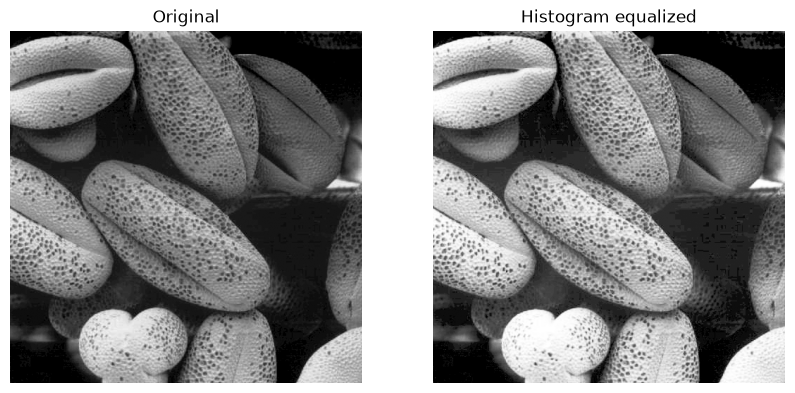

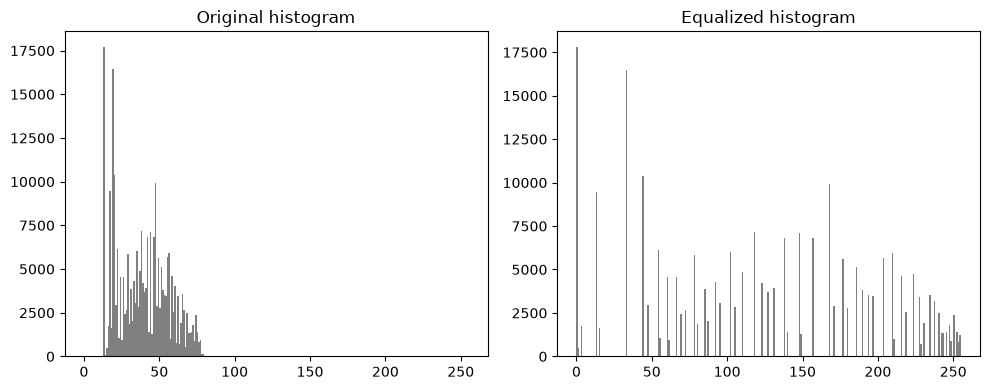

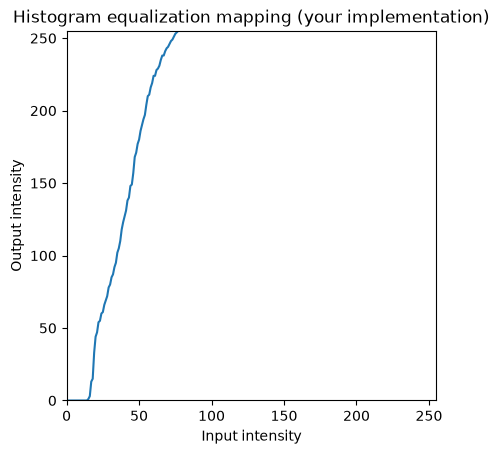

In [48]:
def my_histogram_equalization(img):
    """
    img: single-channel uint8 grayscale image
    Returns: (equalized_image, lut)
    """
    hist = np.bincount(img.ravel(), minlength=256)          # histogram
    cdf = np.cumsum(hist)                                    # cumulative sum
    cdf_min = cdf[cdf > 0].min()                              # smallest nonzero cdf value
    total_pixels = img.size

    # standard histogram equalization formula
    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype('uint8')

    equalized = cv.LUT(img, lut)
    return equalized, lut


# --- Load image ---
img_orig = cv.imread('images/q5.tif', cv.IMREAD_GRAYSCALE)  # <-- match your filename

img_eq, lut = my_histogram_equalization(img_orig)

# --- Optional: sanity check against OpenCV's built-in ---
img_eq_cv = cv.equalizeHist(img_orig)
print("Max abs difference vs cv.equalizeHist:", np.max(np.abs(img_eq.astype(int) - img_eq_cv.astype(int))))

# --- Display original vs equalized images ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_orig, cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_eq, cmap='gray')
axes[1].set_title('Histogram equalized'); axes[1].axis('off')
plt.show()

# --- Histograms before and after ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(img_orig.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original histogram')
axes[1].hist(img_eq.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title('Equalized histogram')
plt.tight_layout()
plt.show()

# --- Optional: the equalization curve (mapping function) itself ---
plt.figure()
plt.plot(lut)
plt.xlim(0, 255); plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.xlabel('Input intensity'); plt.ylabel('Output intensity')
plt.title('Histogram equalization mapping (your implementation)')
plt.show()

### Question 6

#### (a) split image into H/S/V, display in grayscale

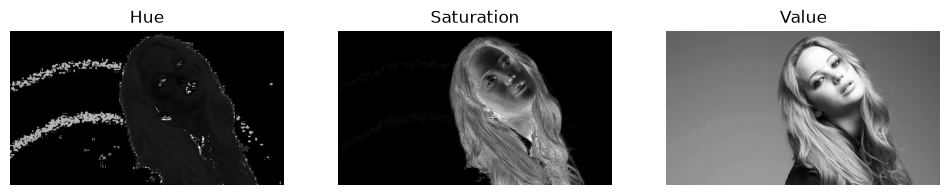

In [49]:
img_bgr = cv.imread('images/q6.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(img_hsv)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(h, cmap='gray'); axes[0].set_title('Hue'); axes[0].axis('off')
axes[1].imshow(s, cmap='gray'); axes[1].set_title('Saturation'); axes[1].axis('off')
axes[2].imshow(v, cmap='gray'); axes[2].set_title('Value'); axes[2].axis('off')
plt.show()

#### (b) Threshold the right plane to extract the foreground mask

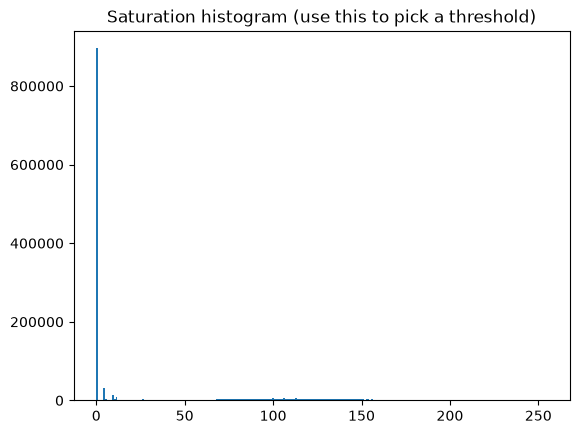

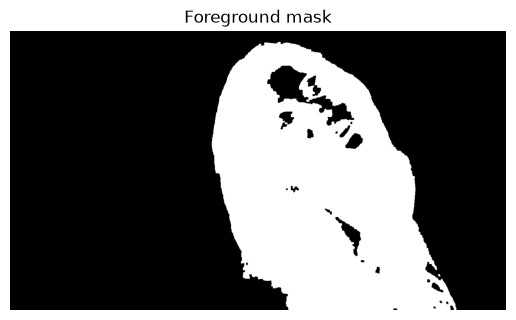

In [50]:
plt.figure()
plt.hist(s.ravel(), bins=256, range=(0, 255))
plt.title('Saturation histogram (use this to pick a threshold)')
plt.show()

thresh_val = 40  # <-- tune based on the histogram above
_, mask = cv.threshold(s, thresh_val, 255, cv.THRESH_BINARY)

# optional cleanup of small noise/holes
kernel = np.ones((5, 5), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)

plt.figure()
plt.imshow(mask, cmap='gray')
plt.title('Foreground mask')
plt.axis('off')
plt.show()

#### (c) Obtain the foreground only using cv.bitwise_and, compute its histogram

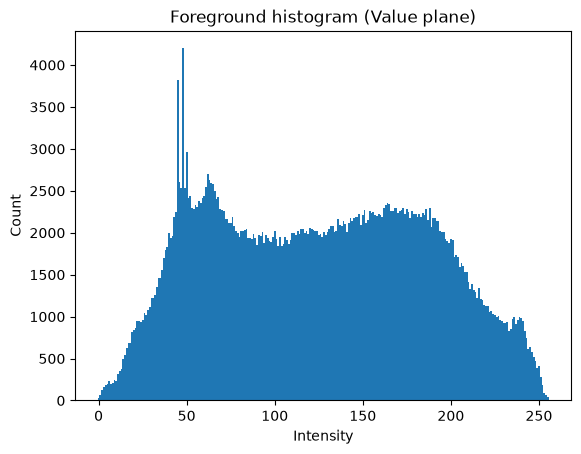

In [51]:
v_foreground = cv.bitwise_and(v, v, mask=mask)

# histogram of foreground only — exclude the masked-out (zero) pixels
fg_pixels = v_foreground[mask > 0]
hist_fg = np.bincount(fg_pixels, minlength=256)

plt.figure()
plt.bar(np.arange(256), hist_fg, width=1)
plt.title('Foreground histogram (Value plane)')
plt.xlabel('Intensity'); plt.ylabel('Count')
plt.show()

#### (d) Cumulative sum of the histogram using np.cumsum

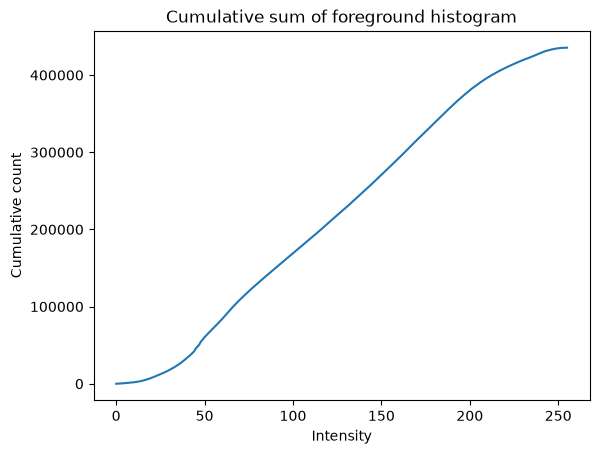

In [52]:
cdf_fg = np.cumsum(hist_fg)

plt.figure()
plt.plot(cdf_fg)
plt.title('Cumulative sum of foreground histogram')
plt.xlabel('Intensity'); plt.ylabel('Cumulative count')
plt.show()

#### (e) Histogram-equalize the foreground

In [53]:
def my_histogram_equalization(pixels, hist, cdf, out_shape):
    cdf_min = cdf[cdf > 0].min()
    total_pixels = pixels.size
    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype('uint8')
    equalized = lut[pixels]  # apply LUT
    return equalized.reshape(out_shape), lut

fg_eq_values, lut = my_histogram_equalization(fg_pixels, hist_fg, cdf_fg, fg_pixels.shape)

# put the equalized values back into a full-size image (zeros outside mask)
v_fg_equalized = np.zeros_like(v)
v_fg_equalized[mask > 0] = fg_eq_values

#### (f) Extract background, add with the equalized foreground

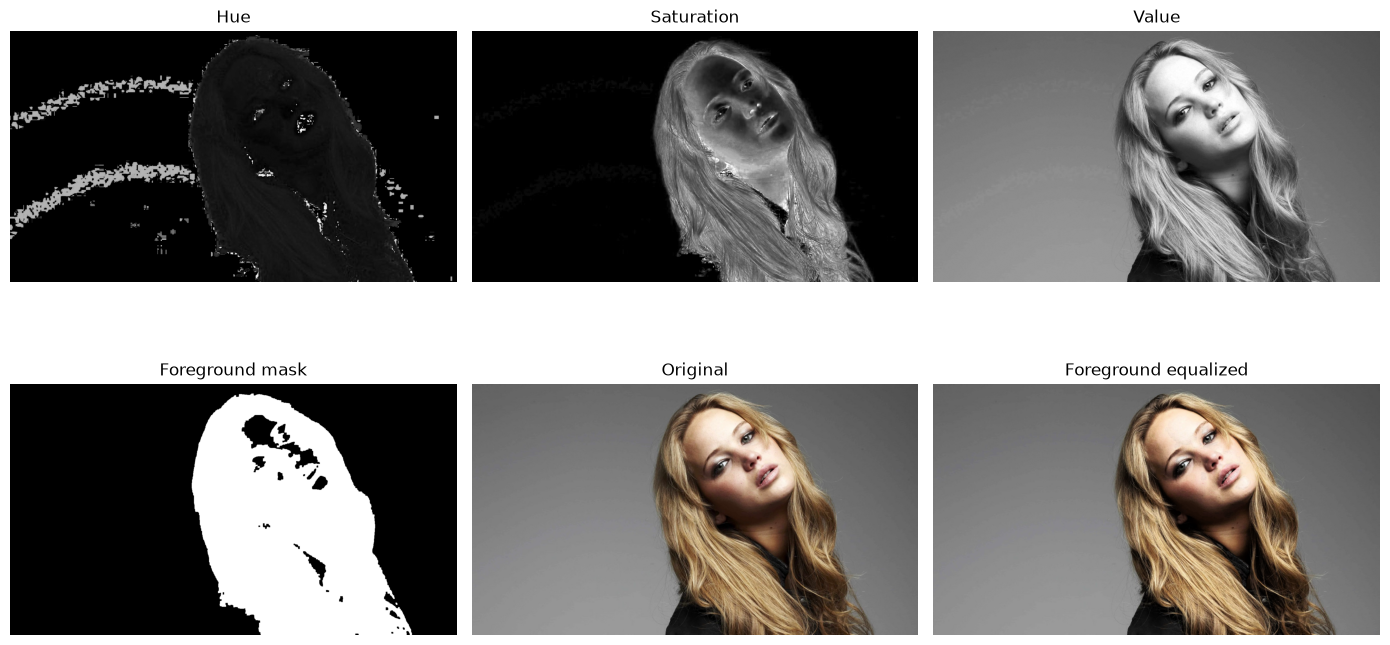

In [54]:
v_background = cv.bitwise_and(v, v, mask=cv.bitwise_not(mask))
v_combined = cv.add(v_background, v_fg_equalized)

img_hsv_result = cv.merge([h, s, v_combined])
img_bgr_result = cv.cvtColor(img_hsv_result, cv.COLOR_HSV2BGR)

# --- Final display: HSV planes, mask, original, result ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0,0].imshow(h, cmap='gray'); axes[0,0].set_title('Hue'); axes[0,0].axis('off')
axes[0,1].imshow(s, cmap='gray'); axes[0,1].set_title('Saturation'); axes[0,1].axis('off')
axes[0,2].imshow(v, cmap='gray'); axes[0,2].set_title('Value'); axes[0,2].axis('off')
axes[1,0].imshow(mask, cmap='gray'); axes[1,0].set_title('Foreground mask'); axes[1,0].axis('off')
axes[1,1].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)); axes[1,1].set_title('Original'); axes[1,1].axis('off')
axes[1,2].imshow(cv.cvtColor(img_bgr_result, cv.COLOR_BGR2RGB)); axes[1,2].set_title('Foreground equalized'); axes[1,2].axis('off')
plt.tight_layout()
plt.show()

### Question 7

#### (a) Using cv.filter2D with the standard Sobel kernel

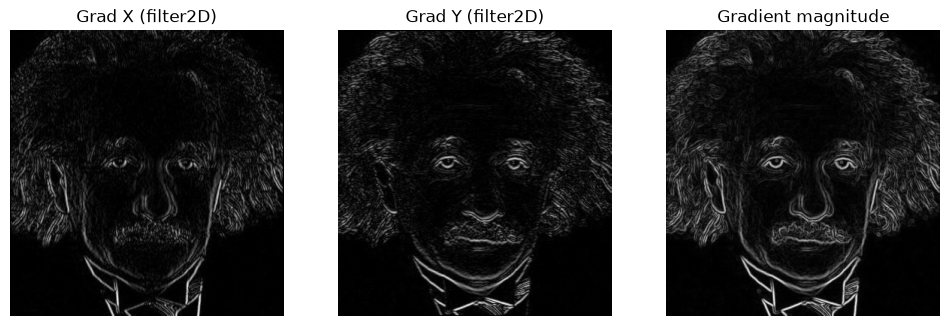

In [55]:
img_orig = cv.imread('images/q7.jpeg', cv.IMREAD_GRAYSCALE)  # <-- match your filename
img_float = img_orig.astype(np.float64)

sobel_x_kernel = np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=np.float64)

sobel_y_kernel = sobel_x_kernel.T  # transpose gives the vertical-edge kernel

grad_x_a = cv.filter2D(img_float, -1, sobel_x_kernel)
grad_y_a = cv.filter2D(img_float, -1, sobel_y_kernel)
grad_mag_a = np.sqrt(grad_x_a**2 + grad_y_a**2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.abs(grad_x_a), cmap='gray'); axes[0].set_title('Grad X (filter2D)'); axes[0].axis('off')
axes[1].imshow(np.abs(grad_y_a), cmap='gray'); axes[1].set_title('Grad Y (filter2D)'); axes[1].axis('off')
axes[2].imshow(grad_mag_a, cmap='gray'); axes[2].set_title('Gradient magnitude'); axes[2].axis('off')
plt.show()

#### (b) manual convolution, no OpenCV filtering call

Max abs difference vs filter2D (grad_x): 1484.0


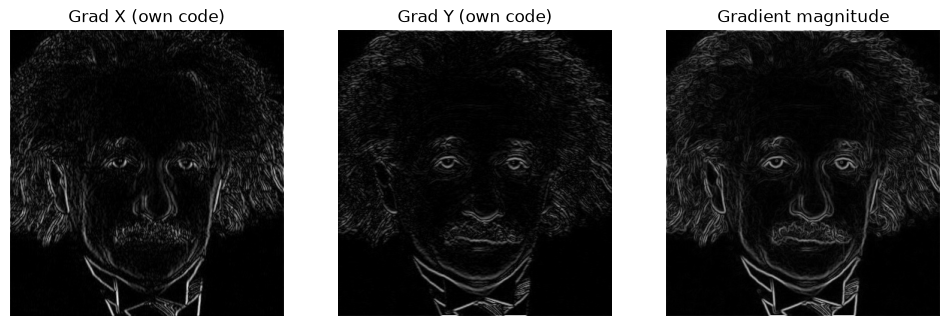

In [56]:
def my_filter2d(img, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    out = np.zeros_like(img, dtype=np.float64)

    # flip the kernel for true convolution (filter2D actually does correlation,
    # so flip here if you want to match cv.filter2D's output exactly)
    kernel_flipped = np.flipud(np.fliplr(kernel))

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel_flipped)
    return out

grad_x_b = my_filter2d(img_float, sobel_x_kernel)
grad_y_b = my_filter2d(img_float, sobel_y_kernel)
grad_mag_b = np.sqrt(grad_x_b**2 + grad_y_b**2)

print("Max abs difference vs filter2D (grad_x):", np.max(np.abs(grad_x_a - grad_x_b)))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.abs(grad_x_b), cmap='gray'); axes[0].set_title('Grad X (own code)'); axes[0].axis('off')
axes[1].imshow(np.abs(grad_y_b), cmap='gray'); axes[1].set_title('Grad Y (own code)'); axes[1].axis('off')
axes[2].imshow(grad_mag_b, cmap='gray'); axes[2].set_title('Gradient magnitude'); axes[2].axis('off')
plt.show()

#### (c) Separable Sobel filtering using the 1D kernel decomposition

Max abs difference vs filter2D (grad_x): 0.0


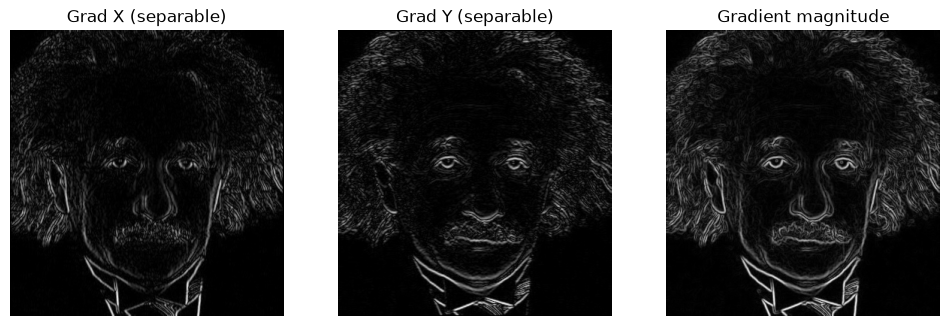

In [57]:
# Sobel_x = [1,2,1]^T * [1,0,-1]   (vertical smoothing, then horizontal derivative)
smooth_kernel = np.array([[1], [2], [1]], dtype=np.float64)      # column vector
deriv_kernel  = np.array([[1, 0, -1]], dtype=np.float64)          # row vector

# Apply the two 1D passes in sequence, once for grad_x...
temp_x = cv.filter2D(img_float, -1, smooth_kernel)   # smooth vertically
grad_x_c = cv.filter2D(temp_x, -1, deriv_kernel)      # differentiate horizontally

# ...and for grad_y, smooth horizontally then differentiate vertically
temp_y = cv.filter2D(img_float, -1, smooth_kernel.T)  # smooth horizontally
grad_y_c = cv.filter2D(temp_y, -1, deriv_kernel.T)    # differentiate vertically

grad_mag_c = np.sqrt(grad_x_c**2 + grad_y_c**2)

print("Max abs difference vs filter2D (grad_x):", np.max(np.abs(grad_x_a - grad_x_c)))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.abs(grad_x_c), cmap='gray'); axes[0].set_title('Grad X (separable)'); axes[0].axis('off')
axes[1].imshow(np.abs(grad_y_c), cmap='gray'); axes[1].set_title('Grad Y (separable)'); axes[1].axis('off')
axes[2].imshow(grad_mag_c, cmap='gray'); axes[2].set_title('Gradient magnitude'); axes[2].axis('off')
plt.show()

### Question 8

### Question 9

#### (a) GrabCut segmentation - mask, foreground, background

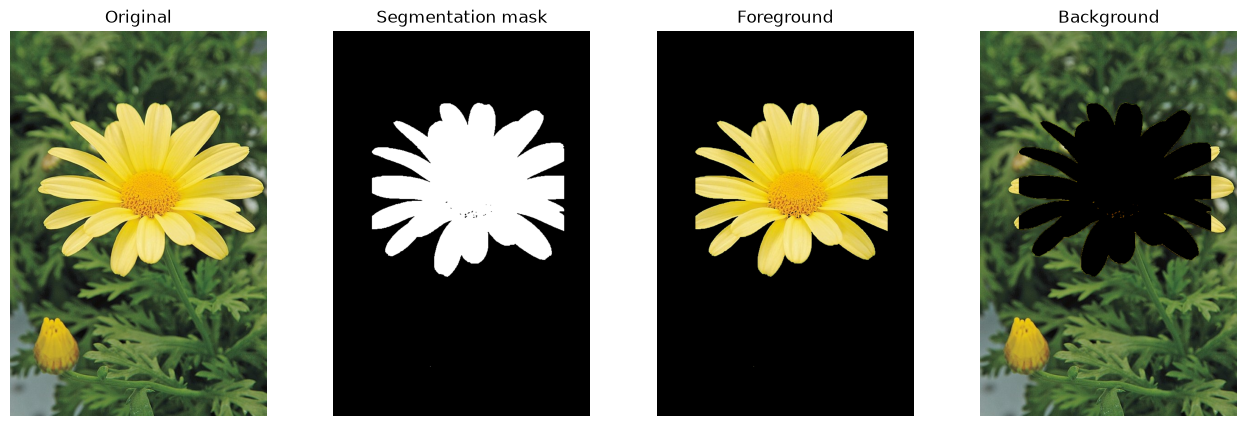

In [58]:
img_bgr = cv.imread('images/q9.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

mask = np.zeros(img_bgr.shape[:2], dtype='uint8')
bgd_model = np.zeros((1, 65), dtype='float64')
fgd_model = np.zeros((1, 65), dtype='float64')

# rectangle roughly enclosing the flower — tune to your image
h, w = img_bgr.shape[:2]
rect = (int(0.15*w), int(0.05*h), int(0.75*w), int(0.85*h))

cv.grabCut(img_bgr, mask, rect, bgd_model, fgd_model, iterCount=5, mode=cv.GC_INIT_WITH_RECT)

# grabCut mask values: 0=bg, 1=fg, 2=probable bg, 3=probable fg
final_mask = np.where((mask == 1) | (mask == 3), 1, 0).astype('uint8')

foreground = img_bgr * final_mask[:, :, np.newaxis]
background = img_bgr * (1 - final_mask[:, :, np.newaxis])

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(final_mask, cmap='gray'); axes[1].set_title('Segmentation mask'); axes[1].axis('off')
axes[2].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB)); axes[2].set_title('Foreground'); axes[2].axis('off')
axes[3].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB)); axes[3].set_title('Background'); axes[3].axis('off')
plt.show()

#### (b) Enhanced image with blurred background

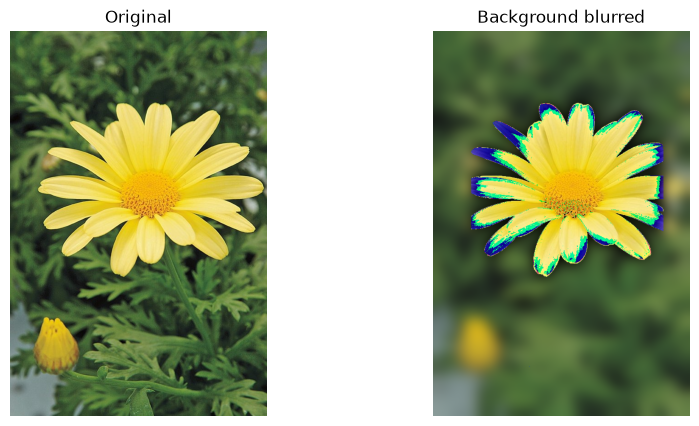

In [59]:
blurred_background = cv.GaussianBlur(background, (0, 0), sigmaX=15)

enhanced = foreground + blurred_background  # foreground is 0 outside mask, so no overlap

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)); axes[1].set_title('Background blurred'); axes[1].axis('off')
plt.show()

#### (c) Why is the background just beyond the edge quite dark?

### Question 10

#### (a) OpenCV's bilateralFilter vs Gaussian blur

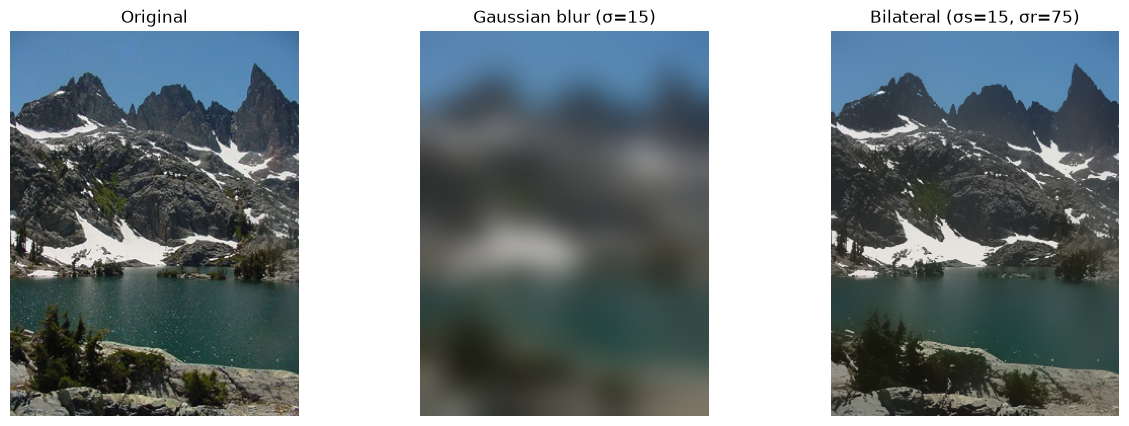

In [60]:
img_bgr = cv.imread('images/q10.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

sigma_s = 15   # spatial sigma (how far in pixels influence reaches)
sigma_r = 75   # range/intensity sigma (how similar in color pixels must be to blend)
d = -1         # neighborhood diameter, computed from sigma_s when negative

bilateral_cv = cv.bilateralFilter(img_bgr, d, sigmaColor=sigma_r, sigmaSpace=sigma_s)

# Gaussian blur with a "similar" kernel — match spatial extent via sigma_s
gaussian_blur = cv.GaussianBlur(img_bgr, (0, 0), sigmaX=sigma_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(gaussian_blur, cv.COLOR_BGR2RGB)); axes[1].set_title(f'Gaussian blur (σ={sigma_s})'); axes[1].axis('off')
axes[2].imshow(cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB)); axes[2].set_title(f'Bilateral (σs={sigma_s}, σr={sigma_r})'); axes[2].axis('off')
plt.show()

#### My own bilateral filter, compared to OpenCV's

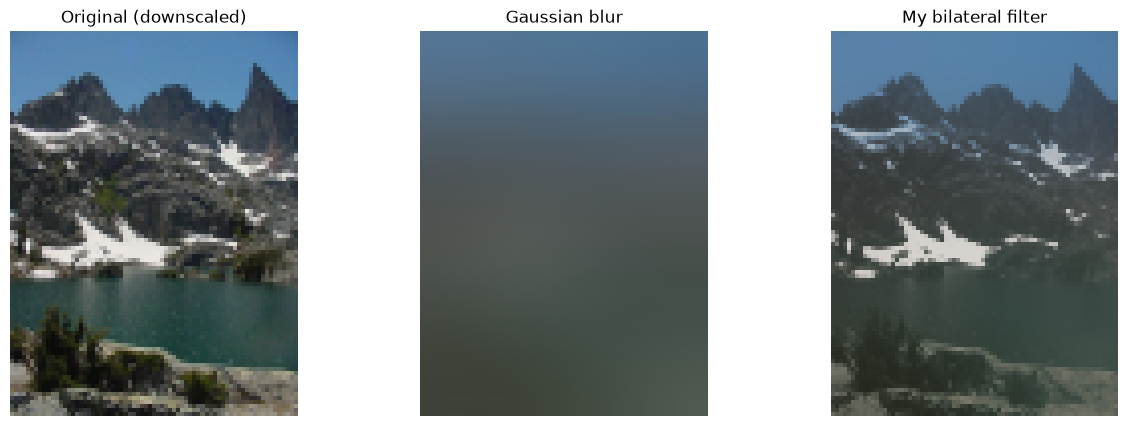

MSE (mine vs cv.bilateralFilter): 88.0511
PSNR (mine vs cv.bilateralFilter): 28.68 dB


In [61]:
def my_bilateral_filter(img, sigma_s, sigma_r, radius=None):
    """
    img: BGR uint8 image
    sigma_s: spatial sigma
    sigma_r: range/intensity sigma
    radius: half-window size (defaults to ~2*sigma_s, rounded)
    """
    if radius is None:
        radius = int(2 * sigma_s)

    img_f = img.astype(np.float64)
    h, w, c = img_f.shape
    padded = np.pad(img_f, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')

    # precompute spatial Gaussian weights (same for every pixel)
    ys, xs = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_weights = np.exp(-(xs**2 + ys**2) / (2 * sigma_s**2))

    out = np.zeros_like(img_f)

    for i in range(h):
        for j in range(w):
            center = padded[i+radius, j+radius]
            window = padded[i:i+2*radius+1, j:j+2*radius+1]

            # range weight based on color difference from center pixel
            diff = window - center
            range_sq = np.sum(diff**2, axis=2)
            range_weights = np.exp(-range_sq / (2 * sigma_r**2))

            weights = spatial_weights * range_weights
            weights_sum = np.sum(weights)

            out[i, j] = np.sum(window * weights[:, :, np.newaxis], axis=(0, 1)) / weights_sum

    return np.clip(out, 0, 255).astype('uint8')

# NOTE: this is a pure-Python nested loop over every pixel — it is slow.
# For a full-resolution photo it can take several minutes. For the assignment,
# either downscale the image first, or run it on a smaller crop, and say so in your report.
img_small = cv.resize(img_bgr, None, fx=0.25, fy=0.25, interpolation=cv.INTER_AREA)

bilateral_mine = my_bilateral_filter(img_small, sigma_s=sigma_s, sigma_r=sigma_r)
bilateral_cv_small = cv.bilateralFilter(img_small, d, sigmaColor=sigma_r, sigmaSpace=sigma_s)
gaussian_small = cv.GaussianBlur(img_small, (0, 0), sigmaX=sigma_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv.cvtColor(img_small, cv.COLOR_BGR2RGB)); axes[0].set_title('Original (downscaled)'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(gaussian_small, cv.COLOR_BGR2RGB)); axes[1].set_title('Gaussian blur'); axes[1].axis('off')
axes[2].imshow(cv.cvtColor(bilateral_mine, cv.COLOR_BGR2RGB)); axes[2].set_title('My bilateral filter'); axes[2].axis('off')
plt.show()

# --- Quantitative comparison: my implementation vs OpenCV's ---
diff = bilateral_mine.astype(np.float64) - bilateral_cv_small.astype(np.float64)
mse = np.mean(diff**2)
psnr = 10 * np.log10((255.0**2) / mse) if mse > 0 else float('inf')

print(f"MSE (mine vs cv.bilateralFilter): {mse:.4f}")
print(f"PSNR (mine vs cv.bilateralFilter): {psnr:.2f} dB")